# Real‑world Credit Card Fraud Detection – Training Notebook
This notebook replaces the old PCA‑based dataset with realistic transaction fields:
`transaction_date`, `transaction_time`, `amount`, `merchant_category`, `country`, `channel`.

It:
- Generates synthetic training data (~60 000 transactions, 1.5 % fraud)
- Engineers behavioural features
- Trains a **Random Forest** classifier
- Saves `fraud_model.pkl` and `scaler.pkl` for later use with `app.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
# ------------------------ Data Generation ------------------------
# If creditcard_raw.csv doesn't exist, generate synthetic transactions.
import random
from pathlib import Path

MERCHANT_CATEGORIES = [
    'retail','grocery','restaurant','gas_station',
    'travel','entertainment','healthcare','online',
    'cash','utilities'
]
CHANNELS = ['web','pos','atm','mobile']
HOME_COUNTRIES = ['US','CA','GB','FR','DE','AU']
FRAUD_COUNTRIES = ['RU','CN','BR','MX']

def _hour_weights():
    w = [1,1,1,1,2,3,4,6,8,8,8,7,7,7,6,6,5,5,5,4,3,3,2,1]
    total = sum(w)
    return [x / total for x in w]

HOUR_WEIGHTS = _hour_weights()

def _card_profile():
    home = random.choice(HOME_COUNTRIES)
    avg_amt = float(np.random.lognormal(3.5, 0.7))   # typical $33
    return {
        'card_last4': np.random.randint(1000, 9999),
        'home_country': home,
        'avg_amount': avg_amt,
        'usual_categories': random.sample(MERCHANT_CATEGORIES, k=random.randint(3,6)),
        'usual_channel': random.choices(CHANNELS, weights=[0.3,0.4,0.1,0.2])[0],
    }

def _normal_txn(profile, base_date, day_offset):
    hour = np.random.choice(range(24), p=HOUR_WEIGHTS)
    dt = base_date + timedelta(days=day_offset, hours=int(hour),
                               minutes=np.random.randint(0,60),
                               seconds=np.random.randint(0,60))
    amount = max(1.0, np.random.normal(profile['avg_amount'], profile['avg_amount']*0.4))
    return {
        'transaction_date': dt.strftime('%Y-%m-%d'),
        'transaction_time': dt.strftime('%H:%M:%S'),
        'card_last4': profile['card_last4'],
        'merchant': f"Merchant_{random.randint(1,400)}",
        'merchant_category': random.choice(profile['usual_categories']),
        'amount': round(amount, 2),
        'country': profile['home_country'] if random.random()<0.95 else random.choice(HOME_COUNTRIES),
        'channel': profile['usual_channel'] if random.random()<0.7 else random.choice(CHANNELS),
        'is_fraud': 0,
    }

def _fraud_txn(profile, base_date, day_offset):
    fraud_hour_weights = [5,5,5,5,4,2,1,1,1,1,1,1,
                          1,1,1,1,1,1,2,2,2,3,4,5]
    total = sum(fraud_hour_weights)
    fraud_hour_probs = [x/total for x in fraud_hour_weights]
    hour = np.random.choice(range(24), p=fraud_hour_probs)
    dt = base_date + timedelta(days=day_offset, hours=int(hour),
                               minutes=np.random.randint(0,60),
                               seconds=np.random.randint(0,60))
    amount = max(50.0, float(np.random.exponential(profile['avg_amount']*4)))
    return {
        'transaction_date': dt.strftime('%Y-%m-%d'),
        'transaction_time': dt.strftime('%H:%M:%S'),
        'card_last4': profile['card_last4'],
        'merchant': f"Merchant_{random.randint(1,400)}",
        'merchant_category': random.choices(['cash','online','travel'], weights=[4,4,2])[0],
        'amount': round(amount, 2),
        'country': random.choice(FRAUD_COUNTRIES),
        'channel': random.choices(['atm','web'], weights=[6,4])[0],
        'is_fraud': 1,
    }

def generate_dataset(n_cards=600, avg_txn_per_card=100, fraud_rate=0.015,
                     output_file='creditcard_raw.csv', seed=42):
    np.random.seed(seed)
    random.seed(seed)
    base_date = datetime(2023,1,1)
    records = []
    for _ in range(n_cards):
        profile = _card_profile()
        n_txn = max(10, int(np.random.normal(avg_txn_per_card, 20)))
        for _ in range(n_txn):
            day_offset = random.randint(0, 364)
            if random.random() < fraud_rate:
                records.append(_fraud_txn(profile, base_date, day_offset))
            else:
                records.append(_normal_txn(profile, base_date, day_offset))
    df = pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)
    df.to_csv(output_file, index=False)
    n_fraud = df['is_fraud'].sum()
    print(f"Generated {len(df):,} transactions | Fraud: {n_fraud:,} ({n_fraud/len(df):.2%})")
    return df

if not Path('creditcard_raw.csv').exists():
    print("Generating synthetic training data …")
    df_raw = generate_dataset()
else:
    df_raw = pd.read_csv('creditcard_raw.csv')
    print(f"Loaded {len(df_raw):,} transactions from creditcard_raw.csv")

Generating synthetic training data …
Generated 60,994 transactions | Fraud: 890 (1.46%)


In [3]:
# ------------------------ Feature Engineering -----------------------
MERCHANT_CATEGORIES_FE = [
    'retail','grocery','restaurant','gas_station',
    'travel','entertainment','healthcare','online',
    'cash','utilities','other'
]
CHANNELS_FE = ['web','pos','atm','mobile','other']
COUNTRIES_FE = [
    'US','CA','GB','FR','DE','AU','JP',
    'CN','RU','BR','MX','IN','other'
]

MODEL_FEATURES = [
    'hour','day_of_week','is_weekend','is_night',
    'amount','amount_log',
    'merchant_category_enc','channel_enc','country_enc',
    'txn_count_last_1h','txn_count_last_24h',
    'avg_amount_prev','amount_ratio',
    'is_new_country','is_new_category',
]

def encode_category(value, category_list):
    value = str(value).lower().strip()
    if value in category_list:
        return category_list.index(value)
    return len(category_list) - 1   # 'other'

def compute_per_card_features(df):
    """Compute per-card behavioral features across the dataset."""
    df = df.copy()
    df['datetime'] = pd.to_datetime(
        df['transaction_date'].astype(str) + ' ' + df['transaction_time'].astype(str)
    )
    df = df.sort_values('datetime').reset_index(drop=True)

    # Basic time / amount / categorical features
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)
    df['amount'] = df['amount'].astype(float)
    df['amount_log'] = np.log1p(df['amount'])
    df['merchant_category_enc'] = df['merchant_category'].apply(
        lambda x: encode_category(x, MERCHANT_CATEGORIES_FE))
    df['channel_enc'] = df['channel'].apply(
        lambda x: encode_category(x, CHANNELS_FE))
    df['country_enc'] = df['country'].apply(
        lambda x: encode_category(x, COUNTRIES_FE))

    # Per‑card behavioural features
    df['txn_count_last_1h'] = 0
    df['txn_count_last_24h'] = 0
    df['avg_amount_prev'] = df['amount']
    df['amount_ratio'] = 1.0
    df['is_new_country'] = 0
    df['is_new_category'] = 0

    ONE_HOUR = np.timedelta64(1, 'h')
    ONE_DAY = np.timedelta64(24, 'h')

    for card, group in df.groupby('card_last4'):
        idxs = group.index.tolist()
        datetimes = group['datetime'].values
        amounts = group['amount'].values
        countries = group['country'].values
        categories = group['merchant_category'].values

        for i, row_idx in enumerate(idxs):
            if i == 0:
                continue
            cur_dt = datetimes[i]
            prev_dts = datetimes[:i]
            df.at[row_idx, 'txn_count_last_1h'] = (prev_dts >= cur_dt - ONE_HOUR).sum()
            df.at[row_idx, 'txn_count_last_24h'] = (prev_dts >= cur_dt - ONE_DAY).sum()
            avg_prev = amounts[:i].mean()
            df.at[row_idx, 'avg_amount_prev'] = avg_prev
            df.at[row_idx, 'amount_ratio'] = amounts[i] / max(avg_prev, 1.0)
            df.at[row_idx, 'is_new_country'] = int(countries[i] not in set(countries[:i]))
            df.at[row_idx, 'is_new_category'] = int(categories[i] not in set(categories[:i]))

    return df

print("Engineering features on the full dataset …")
df_features = compute_per_card_features(df_raw)
df_features.head()

Engineering features on the full dataset …


,transaction_date,transaction_time,card_last4,merchant,merchant_category,amount,country,channel,is_fraud,datetime,...,amount_log,merchant_category_enc,channel_enc,country_enc,txn_count_last_1h,txn_count_last_24h,avg_amount_prev,amount_ratio,is_new_country,is_new_category
0,2023-01-01,00:55:02,8556,Merchant_140,entertainment,5.13,DE,web,0,2023-01-01 00:55:02,...,1.813195,5,0,12,0,0,5.13,1.0,0,0
1,2023-01-01,00:55:06,8314,Merchant_327,retail,73.26,AU,pos,0,2023-01-01 00:55:06,...,4.307572,0,1,12,0,0,73.26,1.0,0,0
2,2023-01-01,01:53:16,2440,Merchant_399,entertainment,75.38,AU,pos,0,2023-01-01 01:53:16,...,4.335721,5,1,12,0,0,75.38,1.0,0,0
3,2023-01-01,02:00:03,6463,Merchant_180,online,144.74,MX,atm,1,2023-01-01 02:00:03,...,4.981824,7,2,12,0,0,144.74,1.0,0,0
4,2023-01-01,02:19:03,4483,Merchant_148,grocery,163.93,CA,atm,0,2023-01-01 02:19:03,...,5.105521,1,2,12,0,0,163.93,1.0,0,0


Fraud rate: 1.46%   (890/60,994)


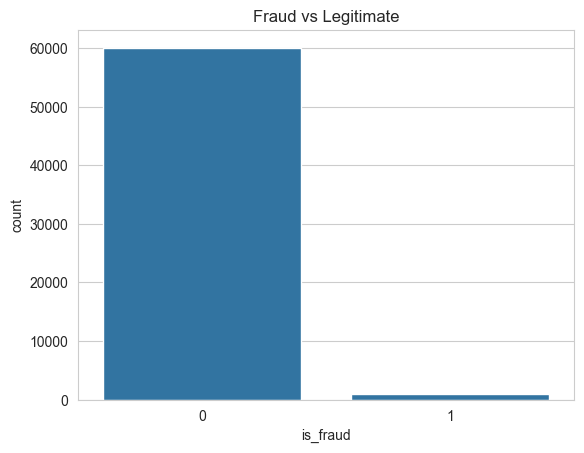

In [4]:
# ------------------------ Target distribution ------------------------
fraud_count = df_features['is_fraud'].sum()
print(f"Fraud rate: {fraud_count / len(df_features):.2%}   ({fraud_count:,}/{len(df_features):,})")
sns.countplot(x='is_fraud', data=df_features)
plt.title("Fraud vs Legitimate")
plt.show()

In [5]:
# ------------------------ Scale & Split ------------------------
X = df_features[MODEL_FEATURES].copy()
y = df_features['is_fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape[0]:,} samples   Test: {X_test.shape[0]:,} samples")

Train: 48,795 samples   Test: 12,199 samples


In [6]:
# ------------------------ Train Random Forest ------------------------
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


Confusion Matrix:
[[12005    16]
 [   12   166]]

Classification Report:
              precision    recall  f1-score   support

           0      0.999     0.999     0.999     12021
           1      0.912     0.933     0.922       178

    accuracy                          0.998     12199
   macro avg      0.956     0.966     0.961     12199
weighted avg      0.998     0.998     0.998     12199



C:\Users\StudyAcer\AppData\Local\Temp\ipykernel_5372\3245991609.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\StudyAcer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


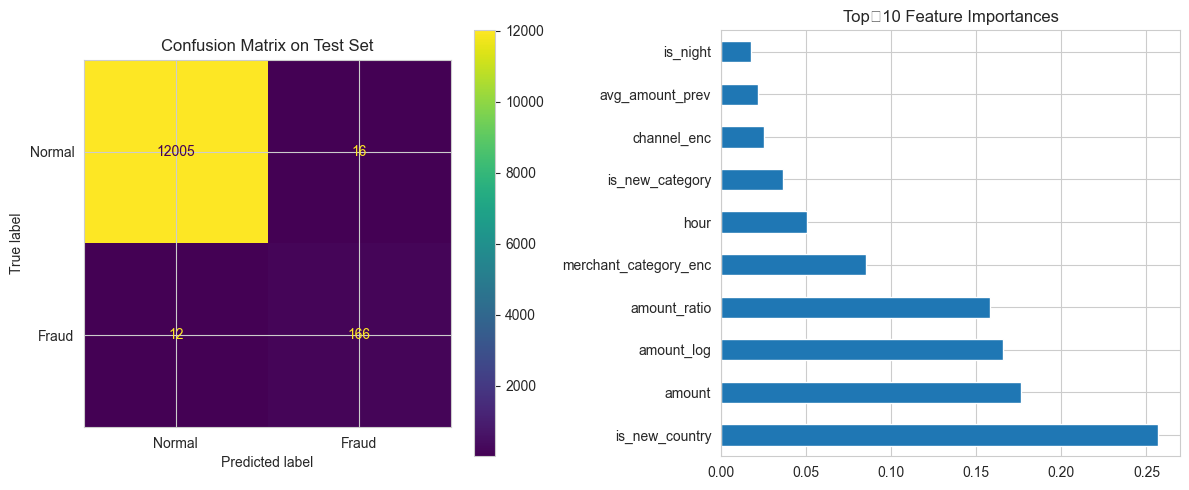

In [7]:
# ------------------------ Evaluation ------------------------
y_pred = model.predict(X_test)
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(ax=ax[0], values_format='d')
ax[0].set_title("Confusion Matrix on Test Set")

# Feature Importance
importances = pd.Series(model.feature_importances_, index=MODEL_FEATURES).nlargest(10)
importances.plot(kind='barh', ax=ax[1])
ax[1].set_title("Top‑10 Feature Importances")
plt.tight_layout()
plt.show()

In [8]:
# ------------------------ Cross‑validation ------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='recall')
print(f"5‑fold CV recall: {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")

5‑fold CV recall: 0.9242 ± 0.0271


In [9]:
# ------------------------ Save model & scaler ------------------------
joblib.dump(model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Saved fraud_model.pkl and scaler.pkl")

✅ Saved fraud_model.pkl and scaler.pkl
